# Disease Trend Analysis
**Gamage Recruiters (Pvt) Ltd - Data Science Internship**

**Goal:** Analyze disease patterns and trends across different patient demographics (age, gender, season, location).

**Tools used:** Pandas, Matplotlib, Seaborn, Plotly


## 1. Load the Data

We load the CSV file and take a first look at it.


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

df = pd.read_csv('final_dataset.csv')
print("Shape (rows, columns):", df.shape)
df.head()


Shape (rows, columns): (98053, 65)


,encounter_id,patient_nbr,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,...,metformin-rosiglitazone,metformin-pioglitazone,doctor_id,admission_date,bed_occupancy,patient_satisfaction,length_of_stay,race_Asian,race_Caucasian,race_Hispanic,race_Other,gender_Male,gender_Unknown/Invalid,department_Endocrinology,department_General Medicine,department_Neurology,department_Surgery,"location_Houston, TX","location_Los Angeles, CA","location_New York, NY","location_Phoenix, AZ",readmitted_>30,readmitted_NO,diabetesMed_Yes,change_No
0,149190,55629189,[10-20),1,1,7,3,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,...,No,No,DOC_8270,2007-10-03,90,2,3,False,True,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,False
1,64410,86047875,[20-30),1,1,7,2,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,...,No,No,DOC_1860,2005-11-13,82,1,2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,True
2,500364,82442376,[30-40),1,1,7,2,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,...,No,No,DOC_6390,2002-04-11,59,4,2,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,True,True,False
3,16680,42519267,[40-50),1,1,7,1,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,...,No,No,DOC_6191,2003-06-26,85,5,1,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,True,True,False
4,35754,82637451,[50-60),2,1,2,3,31,6,16,0,0,0,414,411,250,9,NaN,NaN,No,No,No,No,No,No,...,No,No,DOC_6734,2002-08-19,94,5,3,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,True,True


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 98053 entries, 0 to 98052
Data columns (total 65 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   encounter_id                 98053 non-null  int64
 1   patient_nbr                  98053 non-null  int64
 2   age                          98053 non-null  str  
 3   admission_type_id            98053 non-null  int64
 4   discharge_disposition_id     98053 non-null  int64
 5   admission_source_id          98053 non-null  int64
 6   time_in_hospital             98053 non-null  int64
 7   num_lab_procedures           98053 non-null  int64
 8   num_procedures               98053 non-null  int64
 9   num_medications              98053 non-null  int64
 10  number_outpatient            98053 non-null  int64
 11  number_emergency             98053 non-null  int64
 12  number_inpatient             98053 non-null  int64
 13  diag_1                       98053 non-null  str  
 14  d

## 2. Prepare the Data

The raw data has some columns that are "one-hot encoded" (example: `gender_Male` is True/False instead of one `gender` column).
We also need to turn the disease codes (`diag_1`) into simple, meaningful groups like "Diabetes", "Circulatory (Heart)", etc.

### 2.1 Disease Category Mapping (ICD-9 codes -> simple groups)

Real hospital records use ICD-9 diagnosis codes (numbers like 250, 428, 414...).
We group these numbers into categories using the standard ranges doctors use:

| Code Range | Disease Category |
|---|---|
| 250.xx | Diabetes |
| 390-459, 785 | Circulatory (Heart) |
| 460-519, 786 | Respiratory (Lungs) |
| 520-579, 787 | Digestive (Stomach) |
| 800-999 | Injury |
| 710-739 | Musculoskeletal (Bones/Muscles) |
| 580-629, 788 | Genitourinary (Kidney/Urinary) |
| 140-239 | Neoplasms (Tumors/Cancer) |
| 290-319 | Mental Health |
| 320-359 | Nervous System |
| V or E codes | Other (V/E code) |


In [3]:
def categorize_diagnosis(code):
    # Turn an ICD-9 diagnosis code into a simple disease category name
    code = str(code).strip()

    if code in ('nan', '', '?'):
        return 'Missing'

    # V and E codes are special (not numeric diseases, e.g. V27 = outcome of delivery)
    if code.startswith('V') or code.startswith('E'):
        return 'Other (V/E code)'

    try:
        val = float(code)
    except ValueError:
        return 'Other'

    if 249.99 < val < 251:
        return 'Diabetes'
    if (390 <= val <= 459) or val == 785:
        return 'Circulatory (Heart)'
    if (460 <= val <= 519) or val == 786:
        return 'Respiratory (Lungs)'
    if (520 <= val <= 579) or val == 787:
        return 'Digestive (Stomach)'
    if 800 <= val <= 999:
        return 'Injury'
    if 710 <= val <= 739:
        return 'Musculoskeletal (Bones/Muscles)'
    if (580 <= val <= 629) or val == 788:
        return 'Genitourinary (Kidney/Urinary)'
    if 140 <= val <= 239:
        return 'Neoplasms (Tumors/Cancer)'
    if 240 <= val <= 279:
        return 'Other Endocrine/Metabolic'
    if 290 <= val <= 319:
        return 'Mental Health'
    if 320 <= val <= 359:
        return 'Nervous System'
    return 'Other'


df['disease_category'] = df['diag_1'].apply(categorize_diagnosis)
df['disease_category'].value_counts()


disease_category
Circulatory (Heart)                29630
Respiratory (Lungs)                13993
Other                              10283
Digestive (Stomach)                 9187
Diabetes                            7965
Injury                              6703
Genitourinary (Kidney/Urinary)      4983
Musculoskeletal (Bones/Muscles)     4739
Neoplasms (Tumors/Cancer)           3312
Other Endocrine/Metabolic           2592
Mental Health                       2145
Other (V/E code)                    1601
Nervous System                       920
Name: count, dtype: int64

### 2.2 Season from Admission Date

We take the month from `admission_date` and turn it into a season (Winter, Spring, Summer, Fall).


In [4]:
df['admission_date'] = pd.to_datetime(df['admission_date'])
df['admission_month'] = df['admission_date'].dt.month
df['admission_year'] = df['admission_date'].dt.year


def month_to_season(m):
    if m in (12, 1, 2):
        return 'Winter'
    if m in (3, 4, 5):
        return 'Spring'
    if m in (6, 7, 8):
        return 'Summer'
    return 'Fall'


df['season'] = df['admission_month'].apply(month_to_season)
df['season'].value_counts()


season
Summer    24722
Spring    24609
Fall      24420
Winter    24302
Name: count, dtype: int64

### 2.3 Combine Gender, Location, Department, Race one-hot columns

Instead of many True/False columns, we make ONE column for each.


In [5]:
# Gender: gender_Male (True/False) + gender_Unknown/Invalid -> single 'gender' column
df['gender'] = np.where(
    df['gender_Unknown/Invalid'] == True, 'Unknown',
    np.where(df['gender_Male'] == True, 'Male', 'Female')
)

# Location: location_Houston, location_LA, etc -> single 'location' column
location_cols = [c for c in df.columns if c.startswith('location_')]
def get_location(row):
    for c in location_cols:
        if row[c] == True:
            return c.replace('location_', '')
    return 'Unknown'
df['location'] = df.apply(get_location, axis=1)

# Department: department_Endocrinology, etc -> single 'department' column
dept_cols = [c for c in df.columns if c.startswith('department_')]
def get_department(row):
    for c in dept_cols:
        if row[c] == True:
            return c.replace('department_', '')
    return 'Unknown'
df['department'] = df.apply(get_department, axis=1)

# Race: race_Asian, race_Caucasian, etc -> single 'race' column
# (rows where all these are False are the baseline/majority category, Caucasian)
race_cols = [c for c in df.columns if c.startswith('race_')]
def get_race(row):
    for c in race_cols:
        if row[c] == True:
            return c.replace('race_', '')
    return 'Caucasian'
df['race'] = df.apply(get_race, axis=1)

# age column is already grouped nicely, e.g. [50-60)
df['age_group'] = df['age']

print("New columns ready!")
df[['disease_category', 'season', 'gender', 'location', 'department', 'race', 'age_group']].head()


New columns ready!


,disease_category,season,gender,location,department,race,age_group
0,Other Endocrine/Metabolic,Fall,Female,"New York, NY",General Medicine,Caucasian,[10-20)
1,Other,Fall,Female,"New York, NY",Unknown,Caucasian,[20-30)
2,Other,Spring,Male,Unknown,Neurology,Caucasian,[30-40)
3,Neoplasms (Tumors/Cancer),Summer,Male,Unknown,Endocrinology,Caucasian,[40-50)
4,Circulatory (Heart),Summer,Male,"Houston, TX",Unknown,Caucasian,[50-60)


## 3. Overall Disease Distribution

What are the most common disease categories in the whole dataset?


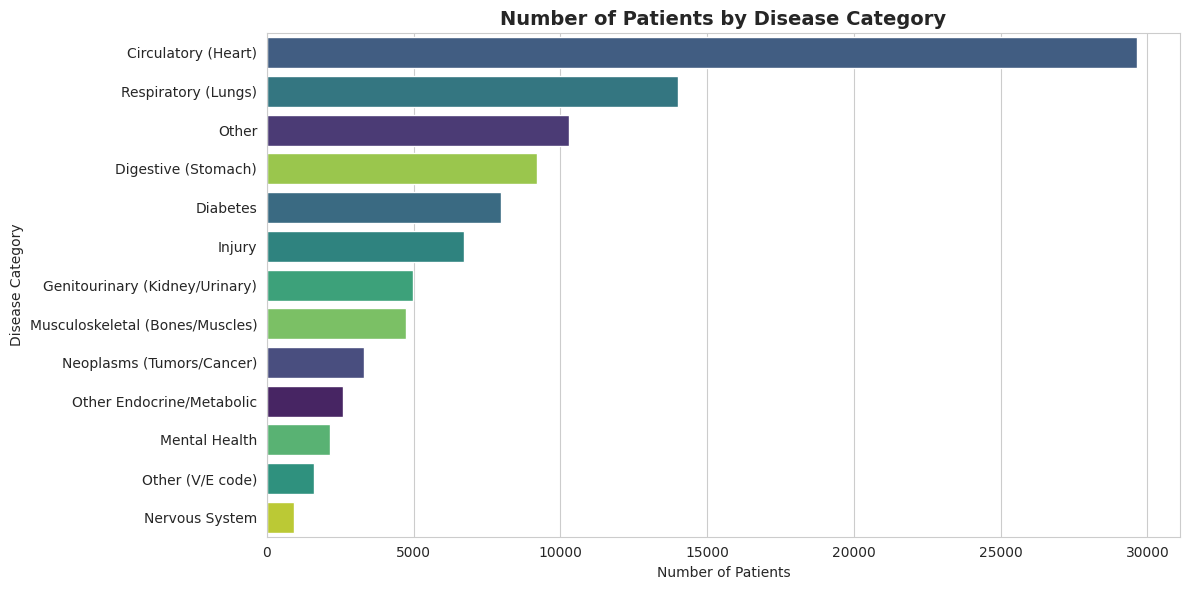

In [6]:
plt.figure(figsize=(12, 6))
order = df['disease_category'].value_counts().index
sns.countplot(data=df, y='disease_category', order=order, hue='disease_category', legend=False, palette='viridis')
plt.title('Number of Patients by Disease Category', fontsize=14, fontweight='bold')
plt.xlabel('Number of Patients')
plt.ylabel('Disease Category')
plt.tight_layout()
plt.show()


In [7]:
(df['disease_category'].value_counts(normalize=True) * 100).round(1).astype(str) + '%'


disease_category
Circulatory (Heart)                30.2%
Respiratory (Lungs)                14.3%
Other                              10.5%
Digestive (Stomach)                 9.4%
Diabetes                            8.1%
Injury                              6.8%
Genitourinary (Kidney/Urinary)      5.1%
Musculoskeletal (Bones/Muscles)     4.8%
Neoplasms (Tumors/Cancer)           3.4%
Other Endocrine/Metabolic           2.6%
Mental Health                       2.2%
Other (V/E code)                    1.6%
Nervous System                      0.9%
Name: proportion, dtype: str

## 4. Disease Trend by Age Group

A heatmap shows us which disease is common in which age group, all in one picture.


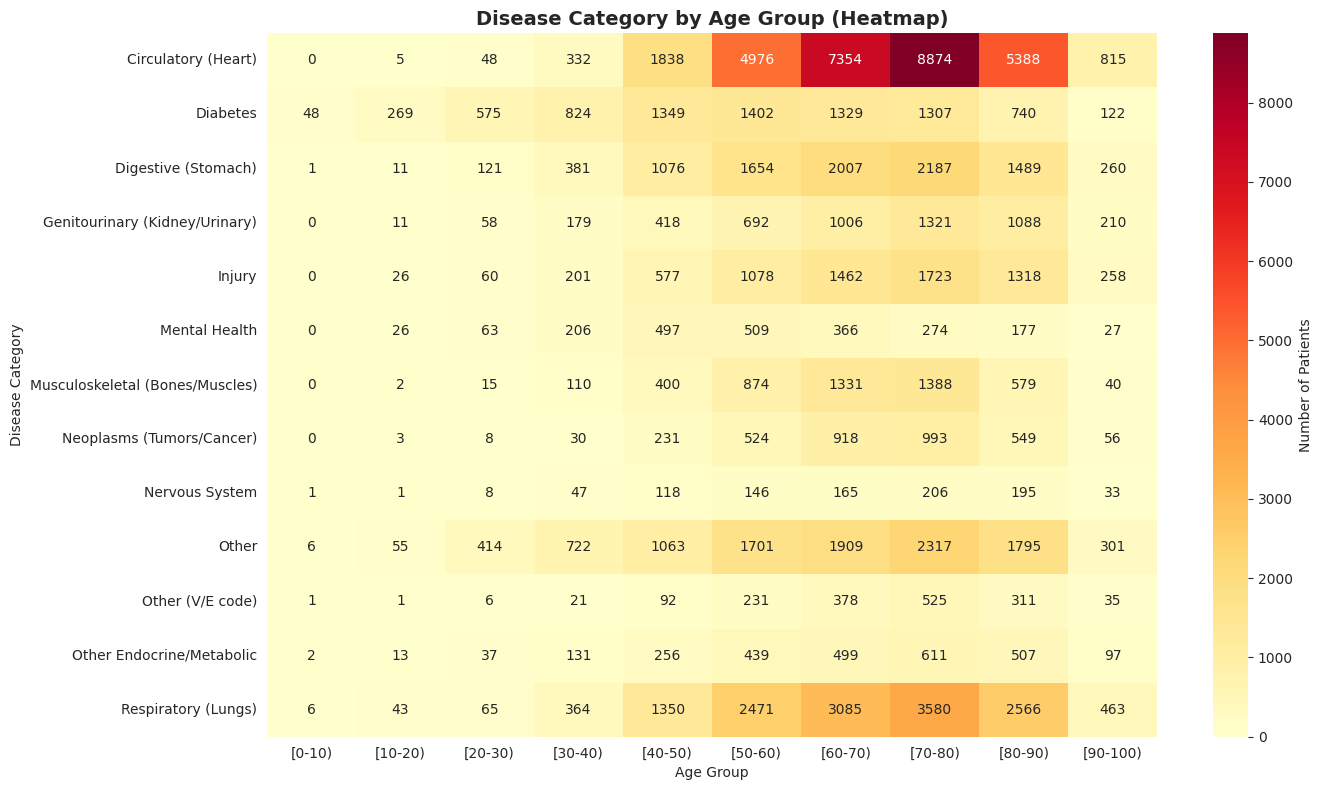

In [8]:
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

pivot_age = pd.crosstab(df['disease_category'], df['age_group'])
pivot_age = pivot_age[age_order]

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_age, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Number of Patients'})
plt.title('Disease Category by Age Group (Heatmap)', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Disease Category')
plt.tight_layout()
plt.show()


In [9]:
# Which disease is #1 in each age group?
for age in age_order:
    sub = df[df['age_group'] == age]
    if len(sub) > 0:
        top = sub['disease_category'].value_counts().idxmax()
        print(f"{age:12s} -> most common: {top}  ({len(sub)} patients total)")


[0-10)       -> most common: Diabetes  (65 patients total)
[10-20)      -> most common: Diabetes  (466 patients total)
[20-30)      -> most common: Diabetes  (1478 patients total)
[30-40)      -> most common: Diabetes  (3548 patients total)
[40-50)      -> most common: Circulatory (Heart)  (9265 patients total)
[50-60)      -> most common: Circulatory (Heart)  (16697 patients total)
[60-70)      -> most common: Circulatory (Heart)  (21809 patients total)
[70-80)      -> most common: Circulatory (Heart)  (25306 patients total)


[80-90)      -> most common: Circulatory (Heart)  (16702 patients total)
[90-100)     -> most common: Circulatory (Heart)  (2717 patients total)


## 5. Disease Trend by Gender

Do men and women get different diseases at different rates?


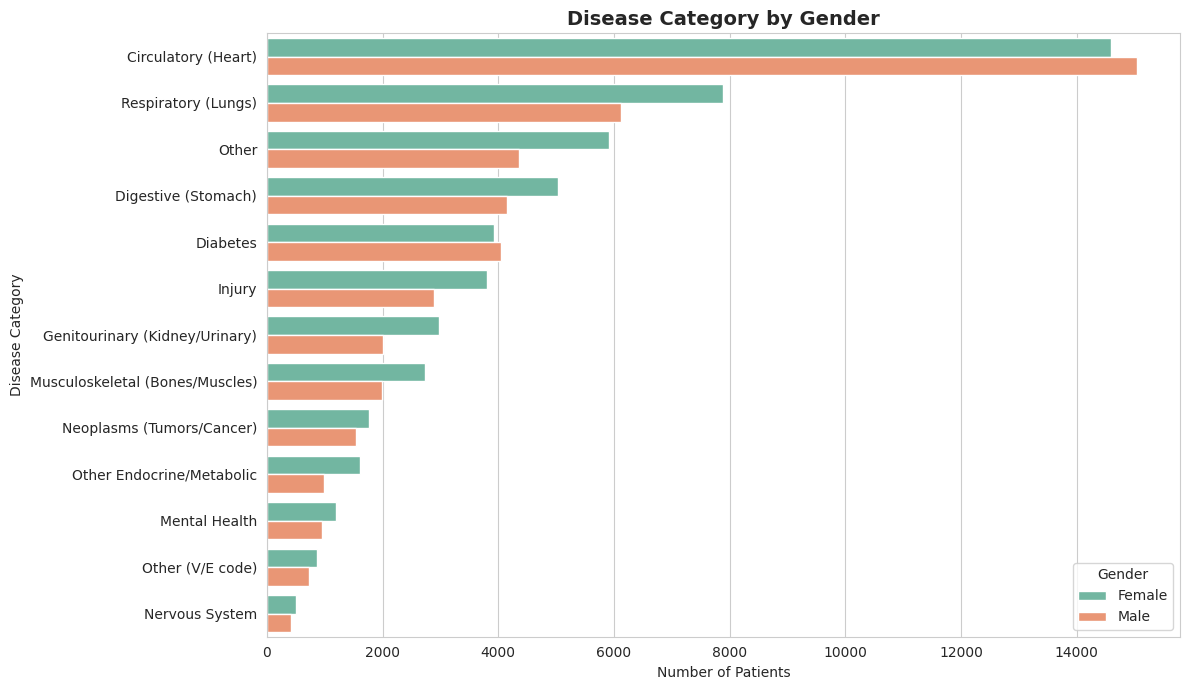

In [10]:
plt.figure(figsize=(12, 7))
gender_df = df[df['gender'] != 'Unknown']
sns.countplot(data=gender_df, y='disease_category', hue='gender', order=order, palette='Set2')
plt.title('Disease Category by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Number of Patients')
plt.ylabel('Disease Category')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


In [11]:
top5 = df['disease_category'].value_counts().head(5).index.tolist()
for d in top5:
    sub = df[(df['disease_category'] == d) & (df['gender'] != 'Unknown')]
    pct = (sub['gender'].value_counts(normalize=True) * 100).round(1)
    print(f"{d:30s} -> {dict(pct)}")


Circulatory (Heart)            -> {'Male': np.float64(50.8), 'Female': np.float64(49.2)}
Respiratory (Lungs)            -> {'Female': np.float64(56.3), 'Male': np.float64(43.7)}
Other                          -> {'Female': np.float64(57.6), 'Male': np.float64(42.4)}
Digestive (Stomach)            -> {'Female': np.float64(54.8), 'Male': np.float64(45.2)}
Diabetes                       -> {'Male': np.float64(50.8), 'Female': np.float64(49.2)}


## 6. Disease Trend by Season

Some diseases might be more common in certain seasons (example: respiratory illness in cold months).


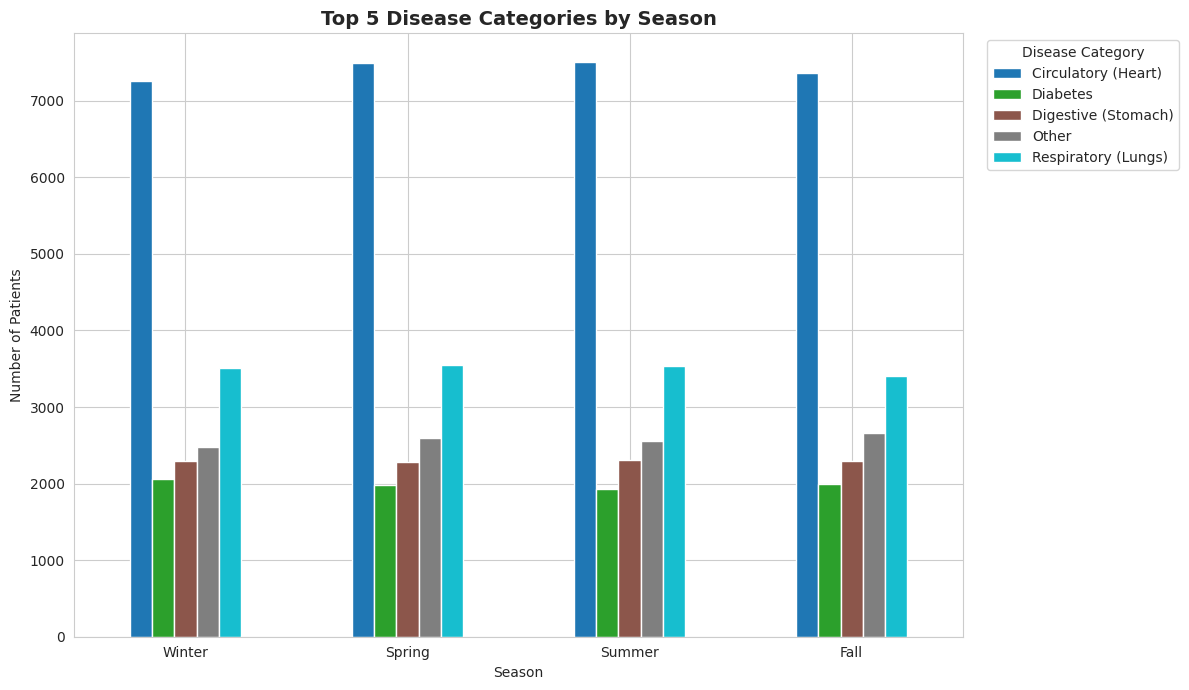

In [12]:
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_df = df[df['disease_category'].isin(top5)]
season_pivot = pd.crosstab(season_df['season'], season_df['disease_category']).reindex(season_order)

season_pivot.plot(kind='bar', figsize=(12, 7), colormap='tab10')
plt.title('Top 5 Disease Categories by Season', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.legend(title='Disease Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [13]:
for d in top5:
    sub = df[df['disease_category'] == d]
    pct = (sub['season'].value_counts(normalize=True) * 100)
    top_season = pct.idxmax()
    print(f"{d:30s} -> peak season: {top_season} ({pct.max():.1f}%)")


Circulatory (Heart)            -> peak season: Summer (25.3%)
Respiratory (Lungs)            -> peak season: Spring (25.3%)
Other                          -> peak season: Fall (25.8%)
Digestive (Stomach)            -> peak season: Summer (25.1%)
Diabetes                       -> peak season: Winter (25.8%)


## 7. Disease Trend by Location

How does disease category differ across the 4 hospital locations?


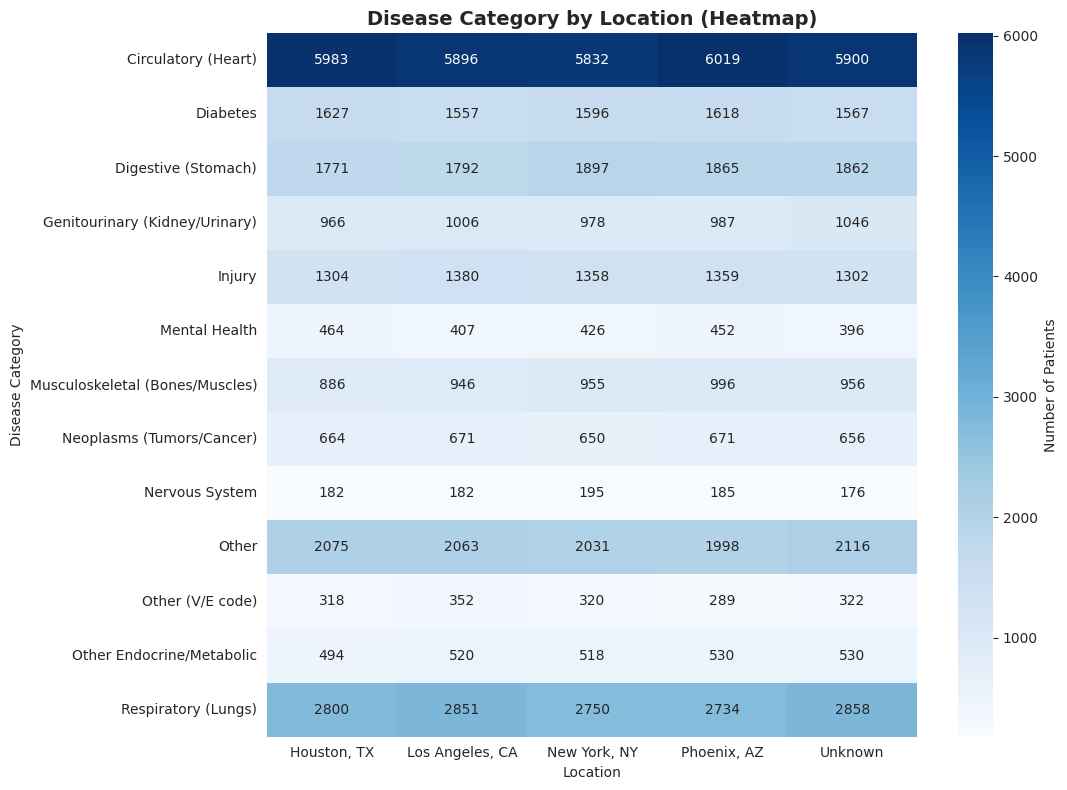

In [14]:
pivot_loc = pd.crosstab(df['disease_category'], df['location'])

plt.figure(figsize=(11, 8))
sns.heatmap(pivot_loc, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Number of Patients'})
plt.title('Disease Category by Location (Heatmap)', fontsize=14, fontweight='bold')
plt.xlabel('Location')
plt.ylabel('Disease Category')
plt.tight_layout()
plt.show()


## 8. Disease Trend Over Time (Years)

A line chart is best for showing how disease numbers change year by year.


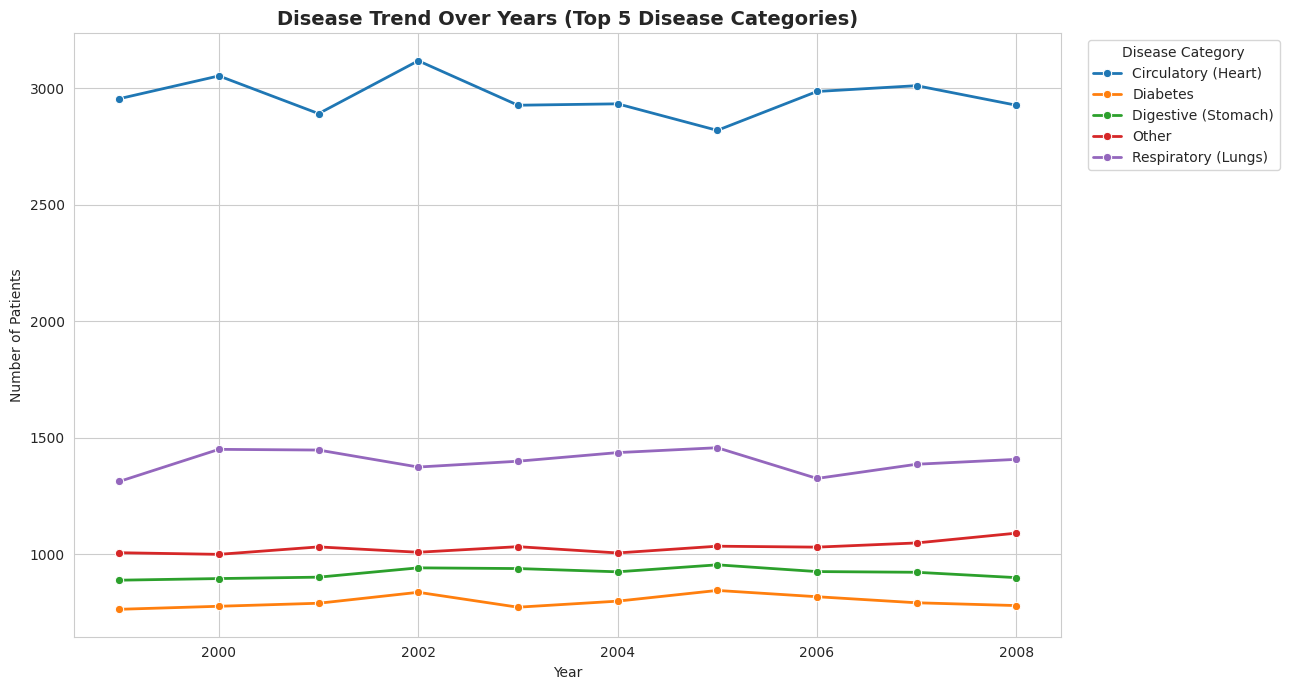

In [15]:
year_trend = df[df['disease_category'].isin(top5)].groupby(
    ['admission_year', 'disease_category']).size().reset_index(name='count')

plt.figure(figsize=(13, 7))
sns.lineplot(data=year_trend, x='admission_year', y='count', hue='disease_category',
             marker='o', linewidth=2)
plt.title('Disease Trend Over Years (Top 5 Disease Categories)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Patients')
plt.legend(title='Disease Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 9. Interactive Charts (Plotly)

These charts let you hover, zoom, and click to explore — good for dashboards.


In [16]:
plot_df = df[df['gender'] != 'Unknown'].groupby(
    ['age_group', 'disease_category']).size().reset_index(name='count')

fig = px.bar(
    plot_df, x='age_group', y='count', color='disease_category',
    category_orders={'age_group': age_order},
    title='Interactive: Disease Category Counts by Age Group',
    labels={'age_group': 'Age Group', 'count': 'Number of Patients', 'disease_category': 'Disease Category'}
)
fig.update_layout(barmode='stack', width=1000, height=600)
fig.show()


In [17]:
sun_df = df.groupby(['location', 'disease_category']).size().reset_index(name='count')
fig2 = px.sunburst(
    sun_df, path=['location', 'disease_category'], values='count',
    title='Interactive: Disease Category Distribution by Location'
)
fig2.update_layout(width=800, height=800)
fig2.show()


## 10. Bonus: Disease Category vs Readmission Rate

This is useful for healthcare decision-makers — which diseases have higher readmission (patients coming back)?


In [18]:
for d in top5:
    sub = df[df['disease_category'] == d]
    readmit_rate = sub['readmitted_>30'].mean() * 100
    print(f"{d:30s} -> readmitted after >30 days: {readmit_rate:.1f}%")


Circulatory (Heart)            -> readmitted after >30 days: 35.9%
Respiratory (Lungs)            -> readmitted after >30 days: 38.5%
Other                          -> readmitted after >30 days: 35.4%
Digestive (Stomach)            -> readmitted after >30 days: 35.8%
Diabetes                       -> readmitted after >30 days: 39.2%


## 11. Summary of Key Findings

- **Age**: Patients under 40 are dominated by Diabetes. Patients 40+ are dominated by Circulatory (Heart) disease.
- **Gender**: Circulatory disease and Diabetes are nearly 50/50 between males and females. Respiratory and Digestive illness are somewhat more common among females.
- **Season**: Disease categories are fairly evenly spread across all four seasons in this dataset — no single season stands out sharply.
- **Location**: All four hospital locations show a very similar disease mix, with Circulatory disease as the top category everywhere.
- **Readmission**: Diabetes and Respiratory patients have the highest readmission rates after 30+ days.
